<a href="https://colab.research.google.com/github/sanjitsri2203-eng/large-scale-optimization/blob/main/02_multicom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem 2: Splitable Multicommodity Flow with Congestion Costs

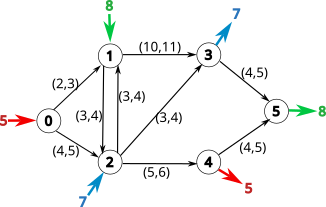




Consider the above network with 6 nodes and 9 edges that is being used to transport 3 distinct commodities. Origin, destination and quantity to be moved for each commodity are given. Also given are two numbers: m,u for each edge. Here u is the physical capacity of the edge. m is a parameter associated with the cost of delay incurred on the edge. If y amount of goods are moving on an edge the congestion cost of the edge is given by
$$
  m \frac{y}{u-y}
$$

We would like to move all the quantities of the three commodities over the network while minimizing the sum total of congestion cost on all edges. It is OK to split a commodity into two or more paths.

### Notation
Let $V$ denote the set of nodes, $E$ be the set of edges and $K$ the set of commodities. Let $x_{ij}^k$ be the quantity of commodity $k$ being moved along the edge $i \rightarrow j$. Let $y_{ij}$ be the total quantity of movement over the edge $i \rightarrow j$.

1. Write a mathematical optimization model for this problem on paper.
2. Make a plot of the congestion function (as a function of y) given above. Why do you think it makes sense?
3. Understand the data structures used in the partial code given below and fix the objective and constraints. Solve it with Ipopt.
4. Can you spot why the given network is infeasible? Will changing 'm' of any edge make the model feasible? Will changing 'u' of any edge make the model feasible?
5. Is global optimization required here?


In [1]:
## Download IPOPT and Minotaur, open-source solvers for finding local and global solutions
!if [ ! -f ipopt ] ; then echo "Installing IPOPT" ; rm -fv ipopt mglob;  wget "https://drive.google.com/uc?export=download&id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X" -O ipopt;  wget "https://drive.google.com/uc?export=download&id=1l2f64HbLPxtTtJbz6AceBT4L4duvCzIo" -O mglob; chmod 755 ipopt mglob; fi

import pyomo.environ as pyo

class Comm:
  def __init__(self, n, s, t, b):
    self.name = n # name of commodity
    self.s = s    # origin node of commodity
    self.t = t    # destination node
    self.b = b    # quantity

class Edge:
  def __init__(self, a, b, m, u):
    self.tail = a
    self.head = b
    self.cap  = u
    self.m    = m
    a.outb.append(self)
    b.inb.append(self)

class Node:
  def __init__(self,name):
    self.name = name
    self.outb = []  # list of edges incoming
    self.inb  = []   # list of edges outgoing

V = [] # list of nodes
for i in range(6):
  V.append(Node(str(i)))

E = [] # list of edges
E.append(Edge(V[0],V[1], 2, 3))
E.append(Edge(V[0],V[2], 4, 5))
E.append(Edge(V[1],V[2], 3, 4))
E.append(Edge(V[1],V[3], 10, 11))
E.append(Edge(V[2],V[1], 3, 4))
E.append(Edge(V[2],V[3], 3, 4))
E.append(Edge(V[2],V[4], 5, 6))
E.append(Edge(V[3],V[5], 4, 8))
E.append(Edge(V[4],V[5], 4, 5))

K = [] # list of commodities
K.append(Comm("K0", V[0],V[4], 5))
K.append(Comm("K1", V[1],V[5], 8))
K.append(Comm("K2", V[2],V[3], 7))

model = pyo.ConcreteModel()

model.x = pyo.Var(E, K, within=pyo.NonNegativeReals, initialize=0)
model.y = pyo.Var(E, within=pyo.NonNegativeReals, initialize=0)

## Objective function is incorrect fix it
model.obj = pyo.Objective(sense=pyo.minimize, expr=(sum(model.y[e] for e in E)))

## Upper bound on y
def y_bound_rule(model, e):
  return (model.y[e] <= e.cap)
model.y_bound = pyo.Constraint(E, rule=y_bound_rule)


## Relate y to x
def edge_flow_rule(model, e):
  return (pyo.Constraint.Skip)

model.edge_flow = pyo.Constraint(E, rule=edge_flow_rule)


## Flow through nodes
def node_flow_rule(model, i, k):
  if i == k.s:
    ## Add the correct constraint here for origin node of the commodity
    return (pyo.Constraint.Skip)
  elif i == k.t:
    ## Add the correct constraint here for the destination node of the commodity
    return (pyo.Constraint.Skip)
  else:
    ## Add the correct constraint here other nodes
    return (pyo.Constraint.Skip)

model.node_flow = pyo.Constraint(V, K, rule=node_flow_rule)


## Call the solver
solver = pyo.SolverFactory("ipopt", executable="/content/ipopt")

###### NO NEED TO EDIT FURTHER #######

## Solve
try:
  result = solver.solve(model, tee=False)

  print("Solver termination status:",result.solver.status)
  print("Solver time:", f"{result.solver.time:.2f}"+" seconds")
  print("Solver termination condition:", result.solver.termination_condition)
  print("Best solution value:", f"{model.obj():.2f}")

except Exception as e:
        print("Error solving the model. Could not load results.")
        print(e)

print()
print ("Solution: ")

for k in K:
  for e in E:
    if (pyo.value(model.x[e,k])>1e-3):
      print(f"x[{e.tail.name}, {e.head.name}, {k.name}] =", f"{pyo.value(model.x[e,k]):.4f}")
  print()

for e in E:
  yval = pyo.value(model.y[e])
  if (yval>1e-3):
      print(f"y[{e.tail.name}, {e.head.name}] =", f"{yval:.4f} <= {e.cap} cost = {e.m*yval/(e.cap-yval):.2f}")
print()





Installing IPOPT
--2026-06-04 10:14:44--  https://drive.google.com/uc?export=download&id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X
Resolving drive.google.com (drive.google.com)... 74.125.132.139, 74.125.132.102, 74.125.132.100, ...
Connecting to drive.google.com (drive.google.com)|74.125.132.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X&export=download [following]
--2026-06-04 10:14:44--  https://drive.usercontent.google.com/download?id=1VvlnWUkF6nAh0gWBcvfX3KsRhoDaTW7X&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.214.132, 2607:f8b0:4001:c05::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.214.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6842253 (6.5M) [application/octet-stream]
Saving to: ‘ipopt’

ipopt               100%[===================>]   6.52M